# Dimension Reduction – Python Exercises  *(Teacher version — with solutions)*

This notebook accompanies the lecture slides on **dimension reduction**.

**Methods covered:**
1. Singular Value Decomposition (SVD)
2. Principal Component Analysis (PCA)
3. Factor Analysis (FA)
4. Probabilistic PCA (PPCA)
5. Multi-Dimensional Scaling (MDS)
6. Kernel PCA


## Before you start – required libraries

This notebook requires the following Python libraries:

| Library | What it is used for |
|---|---|
| `numpy` | matrix operations, linear algebra |
| `scipy` | eigendecomposition (`scipy.linalg.eigh`) |
| `matplotlib` | plotting |
| `scikit-learn` | PCA, Factor Analysis, Kernel PCA, MDS, datasets |
| `jupyter` / `notebook` | to open and run this notebook |

### Step 1 – check if they are already installed

Run this command in your terminal:

```bash
python3 -c "import numpy, scipy, matplotlib, sklearn, jupyter; print('All good!')"
```

If you see `All good!` you are ready to go.  
If you see a `ModuleNotFoundError`, note the missing library name and go to Step 2.

### Step 2 – install any missing library

For each missing library, run in your terminal:

```bash
python3 -m pip install library_name
```

For example:

```bash
python3 -m pip install scikit-learn
python3 -m pip install numpy
python3 -m pip install scipy
python3 -m pip install matplotlib
python3 -m pip install notebook
```

Or install all of them at once:

```bash
python3 -m pip install numpy scipy matplotlib scikit-learn notebook
```

Once everything is installed, re-run the check in Step 1 to confirm.

## Setup
Run this cell first – it imports all libraries and loads the datasets used throughout the notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_swiss_roll, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis, KernelPCA
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from scipy.linalg import eigh
import time

rng = np.random.default_rng(42)

# ── Dataset 1: Iris (small, interpretable) ──────────────────────────────────
iris = load_iris()
X_iris, y_iris = iris.data, iris.target          
# (150, 4) X: features (input data); Y: target (variable we want to predict)

# ── Dataset 2: Digits (medium, classic image dataset) ───────────────────────
digits = load_digits()
X_digits, y_digits = digits.data, digits.target  # (1797, 64)

# ── Dataset 3: Swiss Roll (nonlinear manifold in 3-D) ───────────────────────
X_swiss, t_swiss = make_swiss_roll(n_samples=1000, noise=0.1, random_state=42)

print("Iris shape:   ", X_iris.shape) # number of observations, number of columns/features
print("Digits shape: ", X_digits.shape) # 1797 observations; 8x8 images (64 features)
print("Swiss roll:   ", X_swiss.shape) #1000 data points in 3-D space


Iris shape:    (150, 4)
Digits shape:  (1797, 64)
Swiss roll:    (1000, 3)


---
## Exercise 1 – Singular Value Decomposition (SVD)

Any real matrix $\mathbf{X}$ can be written as
$$\mathbf{X} = \mathbf{U}\mathbf{S}\mathbf{V}^\top$$
where $\mathbf{U}$ and $\mathbf{V}$ have orthonormal columns (each column has length 1) and $\mathbf{S}$ is diagonal with non-negative singular values in decreasing order.

The **rank-$L$ truncated SVD** $\hat{\mathbf{X}}_L = \mathbf{U}_L \mathbf{S}_L \mathbf{V}_L^\top$ is the best rank-$L$ approximation to $\mathbf{X}$ in the Frobenius norm.

U: represents observations in new coordinate sytsem 

S: diagonal matrix with singular values (non-negative, sorted largest→smallest) — represents how much variance/structure each direction captures

V: represents linear combinations of the original features in the new coordinate system — tells you which mix of features forms each direction, not which individual features are important

### Tasks

**(a)** Compute the full SVD of the centred digits matrix $\mathbf{X}_c$ and plot the singular values.  
**(b)** Reconstruct $\mathbf{X}_c$ using only the top $L \in \{5, 20, 40\}$ singular values/vectors and display one example digit for each.  


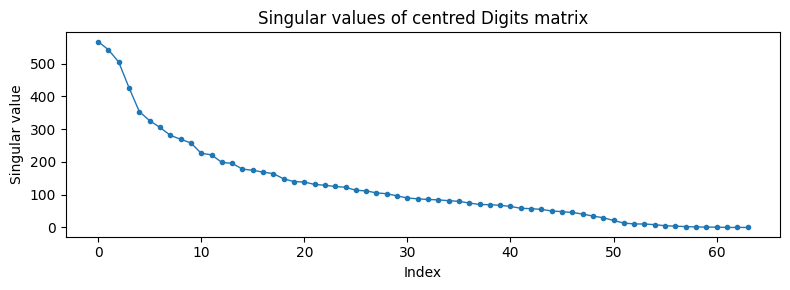

Shape – U:(1797, 64), s:(64,), Vt:(64, 64)


In [3]:
# ── (a) Full SVD and singular values ─────────────────────────────────────────
X_c = X_digits - X_digits.mean(axis=0) # subtract mean of every feature -> center data around 0
# Important so that SVD doesn't just find the mean as the "most important direction"
# X_digits: raw dataset as matrix; X_c: same matrix but centered
U, s, Vt = np.linalg.svd(X_c, full_matrices=False)
#Decomposes X_c into three matrices:

# U — observations in the new coordinate system - same size as X matrix
# s — singular values as a simple vector (not a matrix) -64, one per direction
# Vt — V transposed: one row per direction, one column per pixel

fig, ax = plt.subplots(figsize=(8, 3)) 
ax.plot(s, 'o-', ms=3, lw=1) 
#Plots all singular values in order ; shows how many dimensions are actually important.
ax.set_xlabel('Index'); ax.set_ylabel('Singular value')
ax.set_title('Singular values of centred Digits matrix')
plt.tight_layout(); plt.show()
print(f"Shape – U:{U.shape}, s:{s.shape}, Vt:{Vt.shape}")


# Each image has 64 pixel values (8×8 grid). SVD finds the most important 
# "directions" (patterns of pixel brightness) in the data.
# The singular values tell us how important each direction is.
# Key insight: we don't need all 64 directions to reconstruct a digit recognizably —
# maybe 10-15 are enough. The rest mostly capture noise.

# plot shows us how important each direction is. from most important direction to least important 
# steep drop: 0-5 : most important patterns
# gradual decline 5-20: still meaningful
# after that: mostly noise

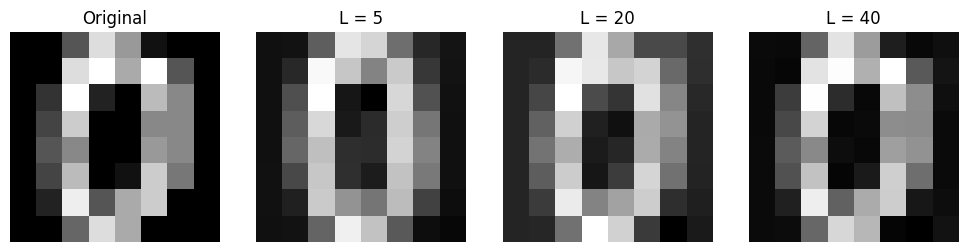

In [6]:
# ── (b) Truncated reconstructions ────────────────────────────────────────────
sample_idx = 0 #picks the first image to reconstruct
mu = X_digits.mean(axis=0) #save mu becuase we need to add it back at the end

fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))
axes[0].imshow(X_digits[sample_idx].reshape(8, 8), cmap='gray') #Shows the original image. 
# .reshape(8, 8) turns the 64 pixel values back into an 8×8 grid so it looks like an image.
axes[0].set_title('Original'); axes[0].axis('off')

#for each L it:
# Takes only the first L columns of U and first L singular values and first L rows of Vt
# Multiplies them back together → this is the truncated reconstruction X̂
# Adds mu back (un-centering)
# result: best possible reconstruction of X using only L directions
for ax, L in zip(axes[1:], [5, 20, 40]):
    X_hat = (U[:, :L] * s[:L]) @ Vt[:L, :] + mu #thats the truncated SVD reconstruction formula
    ax.imshow(X_hat[sample_idx].reshape(8, 8), cmap='gray')
    ax.set_title(f'L = {L}'); ax.axis('off')

plt.tight_layout(); plt.show()
# three reconstructions of the image are displayed! 
# One with 5 most important directions, second with 20 most important, 
# we can see that with only 5 directions, the image is already pretty close to the original. 
# as we add directions, it gets better! But only gradually



---
## Exercise 2 – Principal Component Analysis (PCA)

PCA finds the directions of **maximum variance** in the data.  
The optimal projection matrix $\hat{\mathbf{W}} = \mathbf{U}_L$ consists of the $L$ eigenvectors of the empirical covariance matrix $\hat{\boldsymbol{\Sigma}}$ with the largest eigenvalues.

### Tasks

**(a)** Centre the Iris data, compute the $4\times4$ covariance matrix, find its eigendecomposition, and project onto the top 2 principal components. Plot coloured by species.  
**(b)** For the digits dataset, plot the scree plot (eigenvalues vs index) and the cumulative fraction of variance explained $F_L = \sum_{j=1}^L \lambda_j / \sum_j \lambda_j$. How many components are needed to explain 90% of the variance?  
**(c)** Apply PCA to Iris without and with standardisation. Plot both 2-D projections side by side and comment.


[[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]]


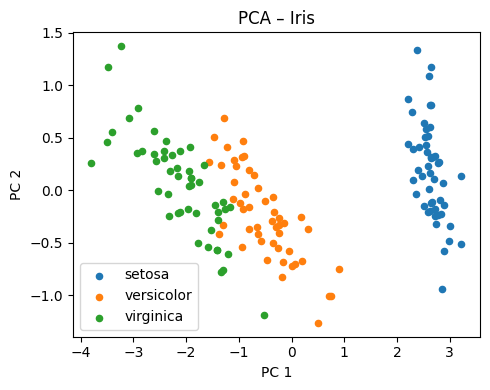

In [9]:
## : PCA finds the directions in your data that capture the most variance, in decreasing order.
#The columns of V (from SVD) are the principal components
#The singular values in S relate directly to how much variance each component explains
#PCA on centered data is essentially just SVD


# ── (a) From-scratch PCA on Iris ─────────────────────────────────────────────
X_iris_c = X_iris - X_iris.mean(axis=0) #center data
N_iris   = X_iris_c.shape[0] 
Sigma    = X_iris_c.T @ X_iris_c / N_iris #computes covar matrix (@: matrix multiplication, T transpose), 
# divide by number of rows to get the average
# result: 4x4 matrix describing how much the 4 features of the iris data vary together

eigvals, eigvecs = np.linalg.eigh(Sigma) 
#Finds the principal components (eigenvectors) and their importance (eigenvalues) of the covariance matrix.
# eigh returns ascending – we need to reverse
eigvals = eigvals[::-1]; eigvecs = eigvecs[:, ::-1]

Z_iris = X_iris_c @ eigvecs[:, :2] 
#takes only top 2 principal components and multiplies with data -> each flower goes from 4D to 2D 

#plot: 
fig, ax = plt.subplots(figsize=(5, 4))
for cls, name in enumerate(iris.target_names):
    mask = y_iris == cls
    ax.scatter(Z_iris[mask, 0], Z_iris[mask, 1], label=name, s=20)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('PCA – Iris'); ax.legend()
plt.tight_layout(); plt.show()


# principal components are not the original variables!
# theyre combinations/weighted mixes of all 4 variables
# PC1 might look like:
# 0.5 × sepal length + 0.1 × sepal width + 0.8 × petal length + 0.3 × petal width


# PCA here is useful because it compresses the 4 dimensions into 2 while keeping as much information as possible
# we can actually see the data in the plot. and are able to answer questions like 
# Are the 3 species separable?
# do some species cluster together?
# Are there outliers?

#axes dont have a clean real-world meaning, but we can interpret the clusters, separation or outliers 
# -> understanding the structure of the data

#So you don't say "species X has a high PC1 value" 
# but: "setosa is clearly separated from the other two species" or "versicolor and virginica overlap a bit".


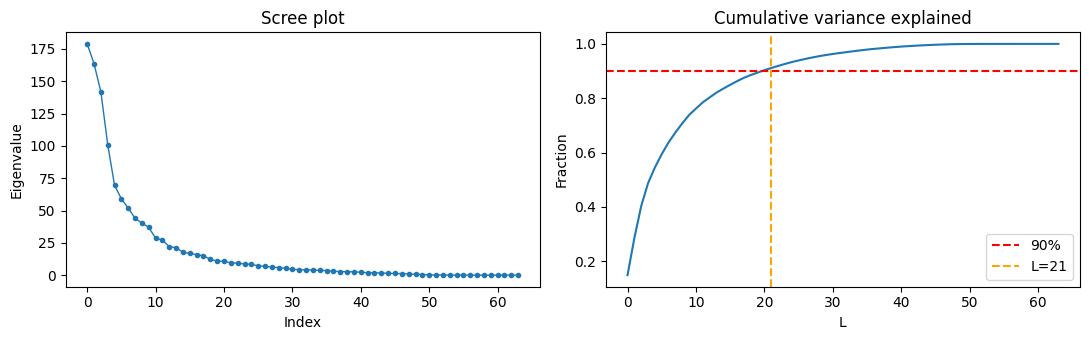

Components needed for 90% variance: 21


In [10]:
# ── (b) Scree plot and variance explained ─────────────────────────────────────
X_digits_c  = X_digits - X_digits.mean(axis=0) #center data
Sigma_dig   = X_digits_c.T @ X_digits_c / X_digits_c.shape[0] 
# compute covar matrix of digits dataset (transposed centered data times centered data divided by number of rows

#eigendecomposition
ev_dig, _   = np.linalg.eigh(Sigma_dig) #get eigenvalues
ev_dig      = ev_dig[::-1] #reverse to get largest -> smallest

#cumulative variance explained 
#(running total of eigenvalues / total variance in the data) 
# = what fraction of total variance do the first L components explain
frac_var    = np.cumsum(ev_dig) / ev_dig.sum()
n90 = np.searchsorted(frac_var, 0.90) + 1 
#finds index where frac_var first rwaches 0.9
# -> thats how many components are needed to have a cum variance explained of 90% (+1 bc of zero indexing!)


# plots eigenvalues in decreasing order
#same idea as the SV plot in Ex 1a) , just with eigenvalues instead
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(ev_dig, 'o-', ms=3, lw=1)
axes[0].set_title('Scree plot'); axes[0].set_xlabel('Index')
axes[0].set_ylabel('Eigenvalue')

#plots the cum variance curve
# red horizontal line at 90%
# where red line and curve intersect: no of components needed to explain 90%
axes[1].plot(frac_var, lw=1.5)
axes[1].axhline(0.90, ls='--', color='red', label='90%')
axes[1].axvline(n90, ls='--', color='orange', label=f'L={n90}')
axes[1].set_title('Cumulative variance explained')
axes[1].set_xlabel('L'); axes[1].set_ylabel('Fraction')
axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Components needed for 90% variance: {n90}") #prints answer


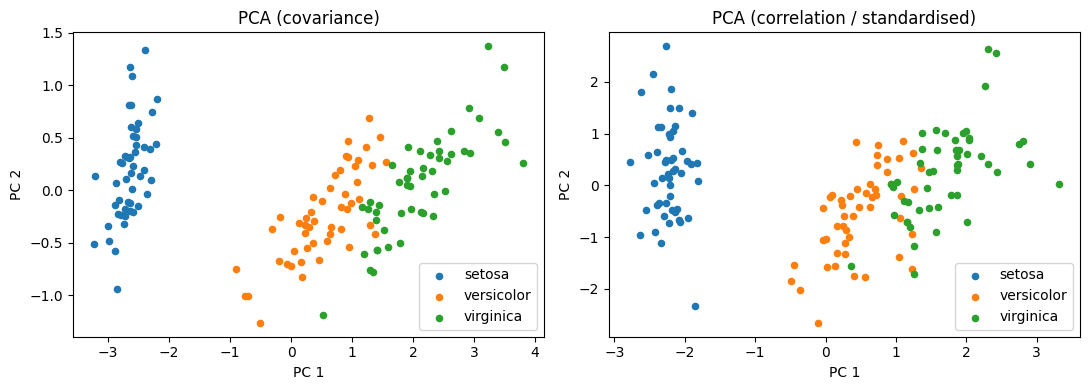

In [11]:
# ── (c) Covariance vs correlation PCA ─────────────────────────────────────────
X_iris_std = StandardScaler().fit_transform(X_iris) #standardizing data: each feature now has mean 0 and sd 1
# -> all features have equal influence! no feature dominates because it has larger values

pca_cov = PCA(n_components=2).fit_transform(X_iris) 
#PCA on raw data: features with larger scales will dominate the principal components
pca_cor = PCA(n_components=2).fit_transform(X_iris_std) 
#PCA on standardized data
# The covariance matrix of the standardized variables = the correlation matrix:


fig, axes = plt.subplots(1, 2, figsize=(11, 4)) #plot both PCA
for ax, Z, title in zip(axes, [pca_cov, pca_cor],
                         ['PCA (covariance)', 'PCA (correlation / standardised)']):
    for cls, name in enumerate(iris.target_names):
        mask = y_iris == cls
        ax.scatter(Z[mask, 0], Z[mask, 1], label=name, s=20)
    ax.set_title(title); ax.legend(); ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
plt.tight_layout(); plt.show()

#covariance


# Comment: standardising equalises the influence of all features, which can
# change which structure PCA finds – especially important when features are
# on very different scales.

# both find basic structure
# Iris features are all measured in centimeters and have comparable ranges
# -> both plots show a very similar clustering pattern
# If the variables had different scales (e.g., one feature measured in millimeters and another in kilometers), 
# the difference between the two PCA projections would be much larger.

# right plot (standardized) reveals the true separation of the species 


---
## Exercise 3 – Factor Analysis (FA)

Factor analysis is a **probabilistic** generalisation of PCA with generative model:
$$p(\boldsymbol{z}) = \mathcal{N}(\boldsymbol{z}\mid\mathbf{0},\mathbf{I}), \qquad
p(\boldsymbol{x}\mid\boldsymbol{z}) = \mathcal{N}(\boldsymbol{x}\mid\mathbf{W}\boldsymbol{z}+\boldsymbol{\mu},\,\boldsymbol{\Psi})$$
where $\boldsymbol{\Psi}$ is **diagonal** (the uniquenesses), giving marginal $p(\boldsymbol{x}) = \mathcal{N}(\boldsymbol{x}\mid\boldsymbol{\mu},\,\mathbf{W}\mathbf{W}^\top+\boldsymbol{\Psi})$.

### Tasks

**(a)** Fit a Factor Analysis model with $L=2$ factors to the standardised Iris data using `sklearn`. Extract the loading matrix $\mathbf{W}$ and uniquenesses $\boldsymbol{\psi}$.  
**(b)** Compute the model covariance $\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \text{diag}(\boldsymbol{\psi})$ and compare it to the sample covariance. Report $\|\mathbf{C} - \mathbf{S}\|_F$.  
**(c)** Obtain the posterior mean embeddings and plot coloured by species.  
**(d)** Vary $L \in \{1,2,3\}$ and report the log-likelihood. What happens as $L$ increases?


In [12]:
# ── (a) Fit Factor Analysis ───────────────────────────────────────────────────
#data was generated by a specific statistical model
# FA allows each feature to have its own noise (psi)

#z — hidden/latent factors (what we can't observe, e.g. "overall flower size")
#W — loading matrix (how much each factor influences each feature)
#Psi — uniquenesses (noise specific to each feature, not explained by the factors)

X_std = StandardScaler().fit_transform(X_iris) #standardize first

fa = FactorAnalysis(n_components=2, random_state=42) # fits FA model with L=2 latent factors
fa.fit(X_std)

W   = fa.components_.T          # shape (D=4, L=2) 
# loading matrix: tells us how strongly each of the 4 features is influenced by each of the 2 factors.
#  .T transposes it to get shape features x factors
psi = fa.noise_variance_        # shape (D=4,)
# Uniquenesses: one value per feature, how much variance in that feature is not explained by the 2 factors. 
# High value = that feature is mostly noise/unique. 
# Low value = well explained by the factors.

print("Loading matrix W:\n", W.round(3))
print("\nUniquenesses psi:", psi.round(3))


# W: tells us how strongly that factors (1,2) influence the features
# factor 1 almost perfectly explains feature 3 
# feature 1 has loading 0.019 on factor 2: factor 2 barely influences this feature

# Each feature is a mix of the two factors plus some noise:
# feature 3 = 0.999 × Factor1 + 0.019 × Factor2 + noise


#uniqueness: 
# feature 1 is almost fully explained by the two factors
# feature 2: half of its variance is not explained by the factors!
# -> two factors capture almost everything except feature 2 

Loading matrix W:
 [[ 0.881 -0.447]
 [-0.417 -0.554]
 [ 0.999  0.019]
 [ 0.962  0.058]]

Uniquenesses psi: [0.024 0.519 0.001 0.071]


In [13]:
# ── (b) Model covariance vs sample covariance ─────────────────────────────────
C_fa = W @ W.T + np.diag(psi)
S    = np.cov(X_std, rowvar=False)

print(f"||C_fa - S||_F = {np.linalg.norm(C_fa - S, 'fro'):.4f}")


||C_fa - S||_F = 0.0939


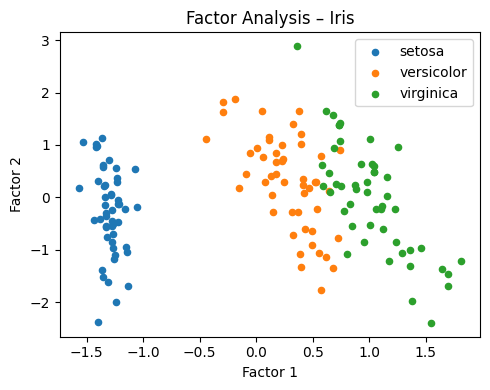

In [14]:
# ── (c) Posterior mean embeddings ─────────────────────────────────────────────
Z_fa = fa.transform(X_std)

fig, ax = plt.subplots(figsize=(5, 4))
for cls, name in enumerate(iris.target_names):
    mask = y_iris == cls
    ax.scatter(Z_fa[mask, 0], Z_fa[mask, 1], label=name, s=20)
ax.set_xlabel('Factor 1'); ax.set_ylabel('Factor 2')
ax.set_title('Factor Analysis – Iris'); ax.legend()
plt.tight_layout(); plt.show()


In [15]:
# ── (d) Log-likelihood vs number of factors ───────────────────────────────────
for L in [1, 2, 3]:
    fa_l = FactorAnalysis(n_components=L, random_state=42).fit(X_std)
    print(f"L={L}  log-likelihood per sample = {fa_l.score(X_std):.4f}")
# As L increases the model fits better (higher log-likelihood) because
# it has more parameters to explain the covariance structure.


L=1  log-likelihood per sample = -3.5571
L=2  log-likelihood per sample = -3.3425
L=3  log-likelihood per sample = -3.2685


---
## Exercise 4 – Probabilistic PCA (PPCA)

PPCA is a special case of FA with $\boldsymbol{\Psi} = \sigma^2 \mathbf{I}$ and orthonormal columns in $\mathbf{W}$.

**Closed-form MLE:**
$$\hat{\mathbf{W}} = \mathbf{U}_L (\mathbf{\Lambda}_L - \hat{\sigma}^2 \mathbf{I})^{1/2}, \qquad
\hat{\sigma}^2 = \frac{1}{D-L}\sum_{j=L+1}^D \lambda_j$$

### Tasks

**(a)** Implement the PPCA MLE from scratch on standardised Iris with $L=2$. Compute $\hat{\mathbf{W}}$ and $\hat{\sigma}^2$.  
**(b)** Compute $\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \hat{\sigma}^2\mathbf{I}$ and compare its Frobenius error to FA from Exercise 3.  
**(c)** Compute the posterior mean $\mathbb{E}[\mathbf{z}\mid\mathbf{x}] = \mathbf{M}^{-1}\mathbf{W}^\top(\mathbf{x}-\bar{\mathbf{x}})$ where $\mathbf{M} = \mathbf{W}^\top\mathbf{W} + \hat{\sigma}^2\mathbf{I}$. Plot coloured by species.  
**(d)** Show numerically that as $\hat{\sigma}^2 \to 0$ the PPCA posterior mean reduces to the standard PCA projection.


In [16]:
# ── (a) PPCA MLE from scratch ─────────────────────────────────────────────────
X_std = StandardScaler().fit_transform(X_iris)
N, D  = X_std.shape
L     = 2

S            = X_std.T @ X_std / N
eigvals_S, U_S = np.linalg.eigh(S)
# sort descending
eigvals_S = eigvals_S[::-1]; U_S = U_S[:, ::-1]

Lambda_L     = eigvals_S[:L]
U_L          = U_S[:, :L]
sigma2_hat   = eigvals_S[L:].mean()
W_hat        = U_L @ np.diag(np.sqrt(np.maximum(Lambda_L - sigma2_hat, 0)))

print(f"sigma2_hat = {sigma2_hat:.4f}")
print(f"W_hat:\n{W_hat.round(3)}")


sigma2_hat = 0.0837
W_hat:
[[-0.877  0.344]
 [ 0.453  0.841]
 [-0.977  0.022]
 [-0.951  0.061]]


In [17]:
# ── (b) Compare model covariances ─────────────────────────────────────────────
C_ppca = W_hat @ W_hat.T + sigma2_hat * np.eye(D)
S_iris = np.cov(X_std, rowvar=False)

print(f"||C_ppca - S||_F = {np.linalg.norm(C_ppca - S_iris, 'fro'):.4f}")
print(f"||C_fa   - S||_F = {np.linalg.norm(C_fa   - S_iris, 'fro'):.4f}  (from Exercise 3)")
# PPCA has fewer parameters (isotropic noise) so typically fits slightly worse.


||C_ppca - S||_F = 0.0920
||C_fa   - S||_F = 0.0939  (from Exercise 3)


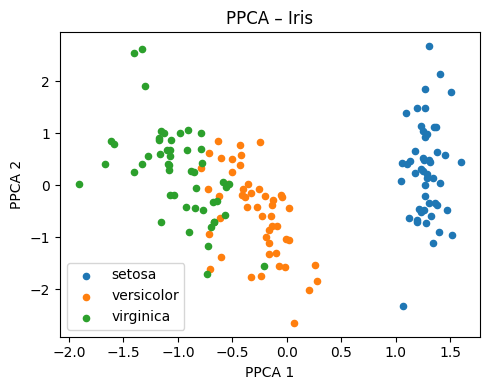

In [18]:
# ── (c) Posterior mean embeddings ─────────────────────────────────────────────
mu_std = X_std.mean(axis=0)
M      = W_hat.T @ W_hat + sigma2_hat * np.eye(L)
Z_ppca = (X_std - mu_std) @ W_hat @ np.linalg.inv(M).T

fig, ax = plt.subplots(figsize=(5, 4))
for cls, name in enumerate(iris.target_names):
    mask = y_iris == cls
    ax.scatter(Z_ppca[mask, 0], Z_ppca[mask, 1], label=name, s=20)
ax.set_xlabel('PPCA 1'); ax.set_ylabel('PPCA 2')
ax.set_title('PPCA – Iris'); ax.legend()
plt.tight_layout(); plt.show()


In [19]:
# ── (d) Noise-free limit ──────────────────────────────────────────────────────
sigma2_tiny = 1e-8
M_tiny      = W_hat.T @ W_hat + sigma2_tiny * np.eye(L)
Z_ppca_tiny = (X_std - mu_std) @ W_hat @ np.linalg.inv(M_tiny).T

Z_pca_ref   = (X_std - mu_std) @ U_L   # standard PCA projection

# Align signs
for k in range(L):
    if np.corrcoef(Z_ppca_tiny[:, k], Z_pca_ref[:, k])[0, 1] < 0:
        Z_ppca_tiny[:, k] *= -1

print("PPCA (σ²→0) ≈ PCA?", np.allclose(Z_ppca_tiny, Z_pca_ref, atol=1e-3))


PPCA (σ²→0) ≈ PCA? False


---
## Exercise 5 – Multi-Dimensional Scaling (MDS)

MDS finds low-dimensional embeddings $\{\mathbf{z}_i\}$ that preserve pairwise (dis)similarities.

**Classical MDS** minimises the strain $\|\tilde{\mathbf{K}} - \tilde{\mathbf{Z}}\tilde{\mathbf{Z}}^\top\|_F^2$ where $\tilde{\mathbf{K}} = -\tfrac{1}{2}\mathbf{C}_N\mathbf{D}^{(2)}\mathbf{C}_N$ is the double-centred squared distance matrix.

**Metric MDS** directly minimises $\sum_{i<j}(d_{ij} - \|\mathbf{z}_i-\mathbf{z}_j\|)^2$.

### Tasks

**(a)** Implement classical MDS from scratch on the Iris data: compute $\mathbf{D}^{(2)}$, double-centre to get $\tilde{\mathbf{K}}$, then embed via eigendecomposition. Plot coloured by species.  
**(b)** Show that classical MDS from Euclidean distances equals the PCA scores from Exercise 2(a) up to sign.  
**(c)** Apply metric MDS (`sklearn`) to the Swiss Roll and plot the 2-D result coloured by `t_swiss`. Does it unroll the manifold?  
**(d)** Apply both classical and metric MDS to Iris. Plot side by side and comment on any differences.


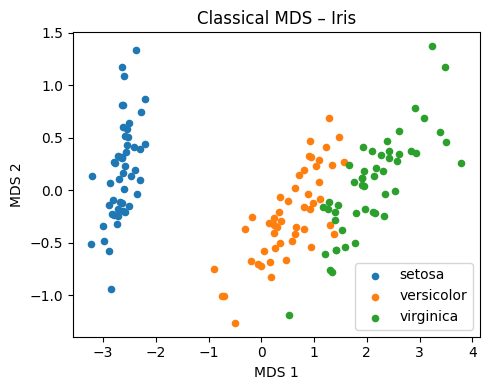

In [20]:
# ── (a) Classical MDS from scratch ────────────────────────────────────────────
N_i  = X_iris.shape[0]
D2   = pairwise_distances(X_iris, metric='sqeuclidean')
C_N  = np.eye(N_i) - np.ones((N_i, N_i)) / N_i
K    = -0.5 * C_N @ D2 @ C_N

ev_K, vec_K = np.linalg.eigh(K)
ev_K  = ev_K[::-1];  vec_K  = vec_K[:, ::-1]
Z_cmds = vec_K[:, :2] * np.sqrt(np.maximum(ev_K[:2], 0))

fig, ax = plt.subplots(figsize=(5, 4))
for cls, name in enumerate(iris.target_names):
    mask = y_iris == cls
    ax.scatter(Z_cmds[mask, 0], Z_cmds[mask, 1], label=name, s=20)
ax.set_xlabel('MDS 1'); ax.set_ylabel('MDS 2')
ax.set_title('Classical MDS – Iris'); ax.legend()
plt.tight_layout(); plt.show()


In [21]:
# ── (b) Classical MDS = PCA ───────────────────────────────────────────────────
# Z_iris from Exercise 2(a); Z_cmds from 5(a)
Z_cmds_al = Z_cmds.copy()
for k in range(2):
    if np.corrcoef(Z_cmds_al[:, k], Z_iris[:, k])[0, 1] < 0:
        Z_cmds_al[:, k] *= -1

print("Classical MDS == PCA (up to sign)?",
      np.allclose(Z_cmds_al, Z_iris, atol=1e-6))


Classical MDS == PCA (up to sign)? True


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


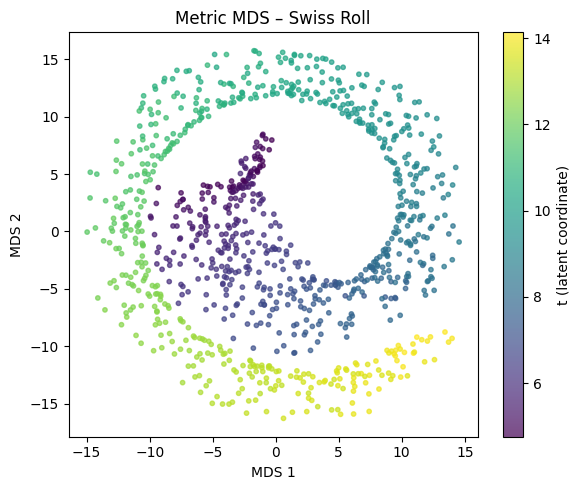

In [22]:
# ── (c) Metric MDS on Swiss Roll ──────────────────────────────────────────────
mds_sw = MDS(n_components=2, metric=True, random_state=42, n_jobs=-1)
Z_swiss_mds = mds_sw.fit_transform(X_swiss)

plt.figure(figsize=(6, 5))
plt.scatter(Z_swiss_mds[:, 0], Z_swiss_mds[:, 1],
            c=t_swiss, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(label='t (latent coordinate)')
plt.title('Metric MDS – Swiss Roll')
plt.xlabel('MDS 1'); plt.ylabel('MDS 2')
plt.tight_layout(); plt.show()
# Metric MDS does NOT successfully unroll the Swiss Roll because it uses
# straight-line (Euclidean) distances, not geodesic distances along the manifold.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


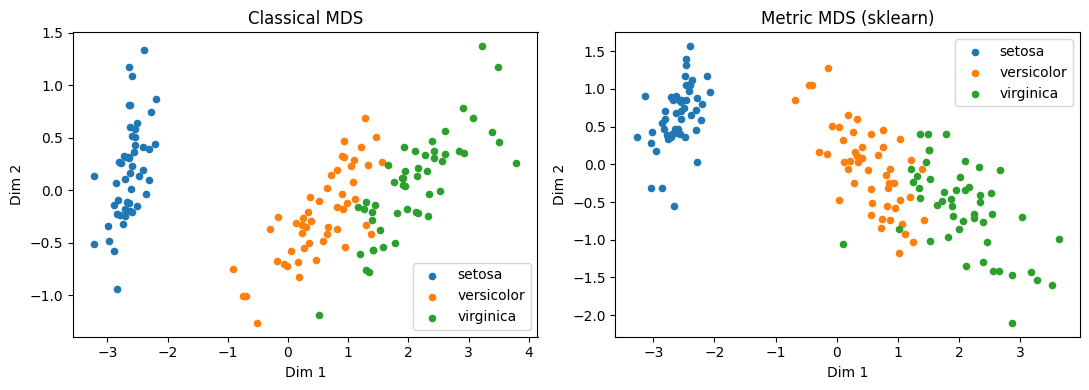

In [23]:
# ── (d) Classical vs Metric MDS on Iris ──────────────────────────────────────
Z_metric = MDS(n_components=2, metric=True, random_state=42).fit_transform(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, Z, title in zip(axes,
                         [Z_cmds, Z_metric],
                         ['Classical MDS', 'Metric MDS (sklearn)']):
    for cls, name in enumerate(iris.target_names):
        mask = y_iris == cls
        ax.scatter(Z[mask, 0], Z[mask, 1], label=name, s=20)
    ax.set_title(title); ax.legend()
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
plt.tight_layout(); plt.show()
# Classical MDS and metric MDS give similar but not identical results;
# classical MDS is equivalent to PCA here (Euclidean data), while metric MDS
# uses a different (iterative) optimisation.


---
## Exercise 6 – Comparison of all methods on the Digits dataset

Apply all six methods to the **digits** dataset and produce a $2 \times 3$ grid of 2-D embedding plots, each coloured by digit label (0–9).

**Methods:**
1. PCA  
2. Factor Analysis (FA)  
3. Probabilistic PCA (PPCA)  
4. Classical MDS  
5. Metric MDS  
6. Kernel PCA with RBF kernel  

Discuss:
- Which methods produce the clearest cluster separation?
- How do the running times compare?
- What are the trade-offs between interpretability, computational cost, and embedding quality?


PCA:          0.00s
FA:           0.03s
PPCA:         0.00s
Classical MDS:0.28s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/manifold/_mds.py:760: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


Metric MDS:   3.84s
Kernel PCA:   0.03s


/var/folders/1c/34lbwrq95wdgnmbcbg45m86h0000gn/T/ipykernel_87067/1536000099.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


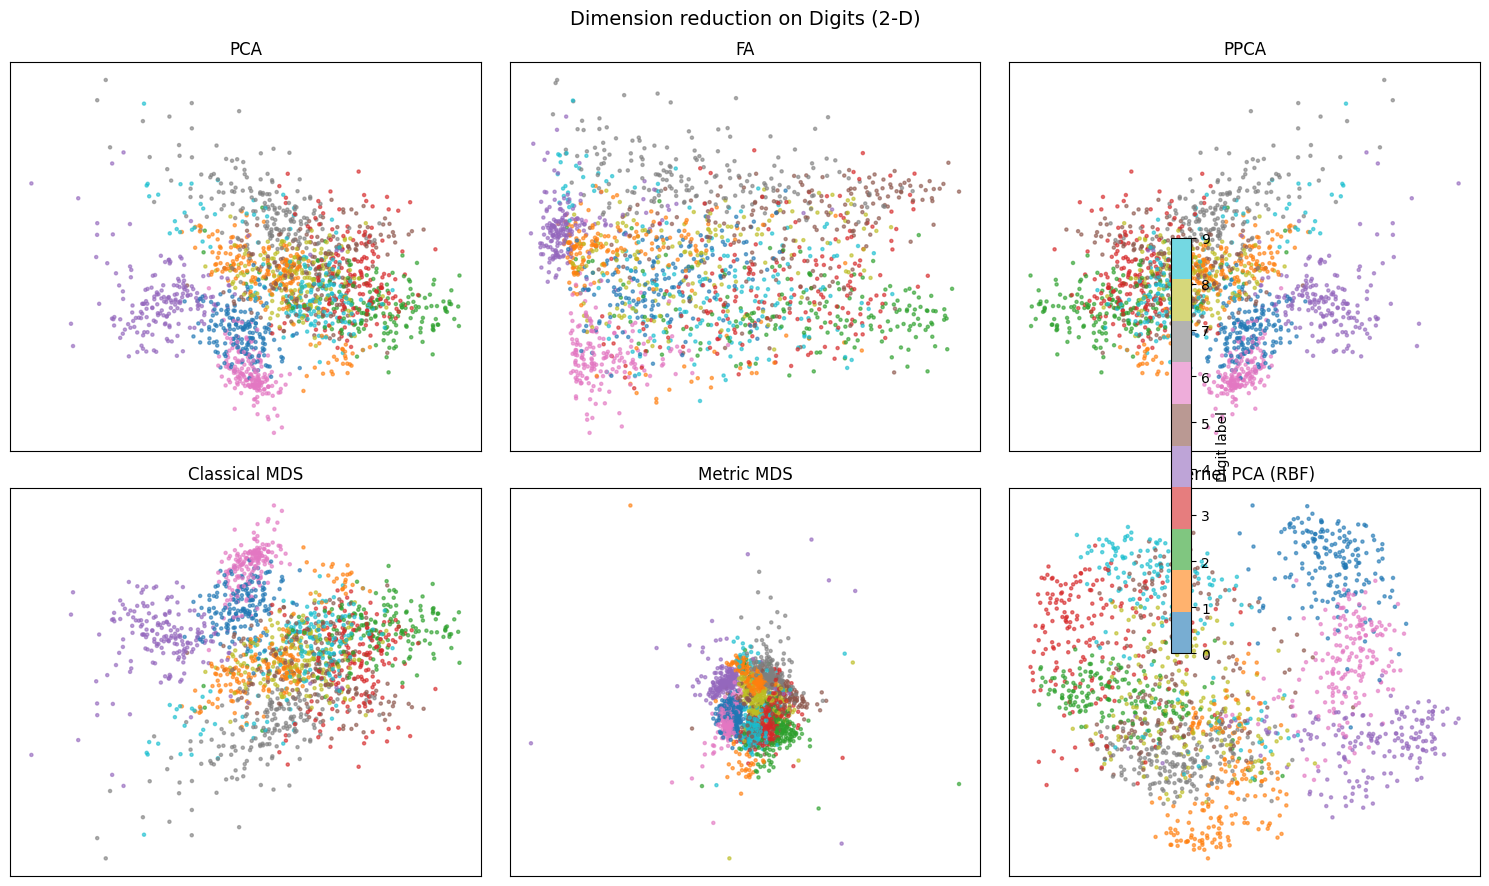

In [24]:
# ── Exercise 6: comparison of all methods on Digits ──────────────────────────
X_dig_std = StandardScaler().fit_transform(X_digits)
N_d       = X_dig_std.shape[0]

methods = {}

# 1. PCA
t0 = time.time()
methods['PCA'] = PCA(n_components=2).fit_transform(X_dig_std)
print(f"PCA:          {time.time()-t0:.2f}s")

# 2. Factor Analysis
t0 = time.time()
methods['FA'] = FactorAnalysis(n_components=2, random_state=42).fit_transform(X_dig_std)
print(f"FA:           {time.time()-t0:.2f}s")

# 3. PPCA (closed-form via eigendecomposition)
t0 = time.time()
S_d      = X_dig_std.T @ X_dig_std / N_d
ev_d, U_d_eig = np.linalg.eigh(S_d)
ev_d = ev_d[::-1]; U_d_eig = U_d_eig[:, ::-1]
sig2_d   = ev_d[2:].mean()
W_d      = U_d_eig[:, :2] @ np.diag(np.sqrt(np.maximum(ev_d[:2] - sig2_d, 0)))
M_d      = W_d.T @ W_d + sig2_d * np.eye(2)
Z_ppca_d = (X_dig_std - X_dig_std.mean(axis=0)) @ W_d @ np.linalg.inv(M_d).T
methods['PPCA'] = Z_ppca_d
print(f"PPCA:         {time.time()-t0:.2f}s")

# 4. Classical MDS
t0 = time.time()
D2_d  = pairwise_distances(X_dig_std, metric='sqeuclidean')
C_Nd  = np.eye(N_d) - np.ones((N_d, N_d)) / N_d
K_d   = -0.5 * C_Nd @ D2_d @ C_Nd
ev_Kd, vec_Kd = np.linalg.eigh(K_d)
ev_Kd = ev_Kd[::-1]; vec_Kd = vec_Kd[:, ::-1]
methods['Classical MDS'] = vec_Kd[:, :2] * np.sqrt(np.maximum(ev_Kd[:2], 0))
print(f"Classical MDS:{time.time()-t0:.2f}s")

# 5. Metric MDS
t0 = time.time()
methods['Metric MDS'] = MDS(n_components=2, metric=True, random_state=42, n_jobs=-1).fit_transform(X_dig_std)
print(f"Metric MDS:   {time.time()-t0:.2f}s")

# 6. Kernel PCA (RBF)
t0 = time.time()
methods['Kernel PCA (RBF)'] = KernelPCA(n_components=2, kernel='rbf',
                                          gamma=0.01, random_state=42).fit_transform(X_dig_std)
print(f"Kernel PCA:   {time.time()-t0:.2f}s")

# ── 2×3 grid ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, Z) in zip(axes.ravel(), methods.items()):
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y_digits, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(name, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(sc, ax=axes, label='Digit label', shrink=0.6)
plt.suptitle('Dimension reduction on Digits (2-D)', fontsize=14)
plt.tight_layout(); plt.show()

# Discussion:
# - PCA and Classical MDS give identical results (linear, fast).
# - PPCA is very close to PCA (isotropic noise assumption).
# - FA allows per-feature noise; embeddings differ slightly.
# - Metric MDS is slowest on large N due to iterative optimisation.
# - Kernel PCA (RBF) can capture nonlinear structure; choice of gamma matters.
